# Day 4 — Random Forest 

Yesterday we learned about Decision Trees. Today we'll see what happens when you take a **bunch of decision trees** and make them work **together**. That's a Random Forest.

---
## 1. First — What is Ensemble Learning?

Before jumping to Random Forest, let's understand the idea behind it.

**Ensemble Learning** simply means: *use multiple models and combine their answers instead of relying on just one.*

**Real-life analogy:**

Imagine you're sick and you visit **one** doctor. They give you a diagnosis. You might think — "Hmm, let me get a second opinion." So you visit 4 more doctors. Now you have **5 opinions**. You go with whatever **most doctors agree on**.

That's ensemble learning. Instead of trusting one model's answer, you ask many models and take the **majority vote**.

> **Key idea:** One model can make mistakes. But if many models vote together, the mistakes tend to cancel out and the correct answer wins.

---
## 2. So What is a Random Forest?

A Random Forest is an **ensemble of decision trees**. That's literally it.

- It creates many decision trees (say 100)
- Each tree looks at the data slightly differently (we'll see how in a moment)
- For a prediction, every tree gives its answer, and the **final answer = majority vote**

```
        Data
       / | \
   Tree1 Tree2 Tree3 ... Tree100
     |     |     |          |
    Cat   Dog   Cat        Cat
              \
               -> Final Answer: Cat (majority wins)
```

It's called "Random" because each tree is trained with some **randomness** baked in (random subsets of data and features). And "Forest" because... well, it's a bunch of trees.

---
## 3. Decision Tree vs Random Forest

Let's compare the two side by side:

| | Decision Tree | Random Forest |
|---|---|---|
| **Number of trees** | Just 1 | Many (typically 100+) |
| **Overfitting** | Overfits easily — memorises training data | Much less overfitting — trees correct each other |
| **Accuracy** | Decent | Usually better |
| **Speed** | Fast to train | Slower (has to train many trees) |
| **Interpretability** | Easy — you can draw and read the tree | Harder — you can't easily visualise 100 trees |
| **Stability** | Small changes in data -> very different tree | More stable — results don't change much |

**In short:**
- Decision Tree = one student answering a test alone
- Random Forest = a group of students discussing and voting on answers

---
## 4. Why Are Many Trees Better Than One?

This is the most important idea to understand.

A single decision tree has a problem — it's **sensitive**. Change a few data points and the entire tree structure can change. It can also memorise weird patterns (noise) in the training data.

Random Forest fixes this by introducing **two types of randomness**:

### a) Random data — Bagging
Each tree gets a **random sample** of the training data (with replacement). So Tree 1 might see rows [1, 3, 3, 5, 7] and Tree 2 might see rows [2, 4, 4, 6, 7]. This means each tree learns from a slightly different perspective.

### b) Random features
At each split, a tree doesn't look at *all* features. It picks a **random subset** of features and chooses the best split from those. This forces trees to be different from each other.

**Why does this help?**

Think of it like this — if all 100 trees saw the exact same data and exact same features, they'd all be identical. That's pointless. But because each tree sees different data and different features, they each make **different mistakes**.

When you average out many different mistakes -> the errors cancel out -> you get a **better overall answer**.

> **Analogy:** Ask 1 person to guess the number of candies in a jar — they might be way off. Ask 100 people and take the average — it'll be surprisingly close to the real number. This is called the **wisdom of the crowd**.

---
## 5. Let's See It in Code

We'll use the **sales_data.xlsx** dataset to predict the **Revenue_Tier** (Low / Medium / High) based on sales features like Price, Quantity, and more.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
# Load sales data
df = pd.read_excel("sales_data.xlsx")
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Dataset shape: (85, 13)

Columns: ['Transaction_ID', 'Date', 'Product', 'Category', 'Price', 'Quantity', 'Revenue', 'Day', 'DayOfWeek', 'WeekNumber', 'Revenue_Per_Unit', 'Revenue_Tier', 'Is_High_Value']


,Transaction_ID,Date,Product,Category,Price,Quantity,Revenue,Day,DayOfWeek,WeekNumber,Revenue_Per_Unit,Revenue_Tier,Is_High_Value
0,TXN-1001,2026-01-07,Headphones,Accessories,150,2,300,7,Wednesday,2,150,Low,No
1,TXN-1002,2026-01-20,Smartphone,Electronics,600,4,2400,20,Tuesday,4,600,High,Yes
2,TXN-1003,2026-01-29,Smartphone,Electronics,600,3,1800,29,Thursday,5,600,Medium,Yes
3,TXN-1004,2026-01-15,Headphones,Accessories,150,1,150,15,Thursday,3,150,Low,No
4,TXN-1005,2026-01-11,Headphones,Accessories,150,4,600,11,Sunday,2,150,Medium,No


In [5]:
# Prepare features and target
# Target: Revenue_Tier (Low / Medium / High)
# Features: numeric columns + encoded categorical columns

# Encode categorical columns
le_product = LabelEncoder()
le_category = LabelEncoder()
le_day_of_week = LabelEncoder()

df["Product_Encoded"] = le_product.fit_transform(df["Product"])
df["Category_Encoded"] = le_category.fit_transform(df["Category"])
df["DayOfWeek_Encoded"] = le_day_of_week.fit_transform(df["DayOfWeek"])

# Select features for the model
feature_cols = ["Price", "Quantity",  "Day", "WeekNumber",
                 "Product_Encoded", "Category_Encoded", "DayOfWeek_Encoded"]

X = df[feature_cols]
y = df["Revenue_Tier"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"\nTarget classes: {y.unique()}")

Training samples: 68
Testing samples:  17

Target classes: <ArrowStringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str


In [6]:

# Train a single Decision Tree
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

# Train a Random Forest (100 trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Both models trained!")

Both models trained!


In [7]:
# Compare accuracy
dt_acc = accuracy_score(y_test, dt.predict(X_test)) * 100
rf_acc = accuracy_score(y_test, rf.predict(X_test)) * 100

print(f"Decision Tree accuracy: {dt_acc:.1f}%")
print(f"Random Forest accuracy: {rf_acc:.1f}%")

Decision Tree accuracy: 76.5%
Random Forest accuracy: 88.2%


With real-world sales data, you can see how Random Forest compares to a single Decision Tree. Random Forest typically gives more stable and accurate results, especially on noisier data.

---
## 6. Seeing the "Many Trees" Advantage

Let's prove that more trees -> more stable and better results. We'll train forests of different sizes and plot their accuracy.

In [9]:
tree_counts = [1, 5, 10, 25, 50, 100, 200,300]
accuracies = []

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test)) * 100
    accuracies.append(acc)
print(accuracies)

[64.70588235294117, 82.35294117647058, 76.47058823529412, 82.35294117647058, 94.11764705882352, 88.23529411764706, 88.23529411764706, 88.23529411764706]


You'll usually see that accuracy improves and **stabilises** as you add more trees. After a point (around 50–100), adding more trees doesn't help much — it just makes training slower.

---
## 7. Feature Importance

One of the most useful things about Random Forest is that it can tell you **which features matter the most** for making predictions.

**How does it work?**

Simple idea: if a feature is used a lot across many trees for making splits, and those splits do a good job of separating the data — that feature is **important**.

If a feature is barely used or doesn't improve predictions much — it's **not important**.

The importance values always add up to 1 (or 100%). So you can think of it as — "What percentage of the prediction power comes from each feature?"

Let's visualise it:

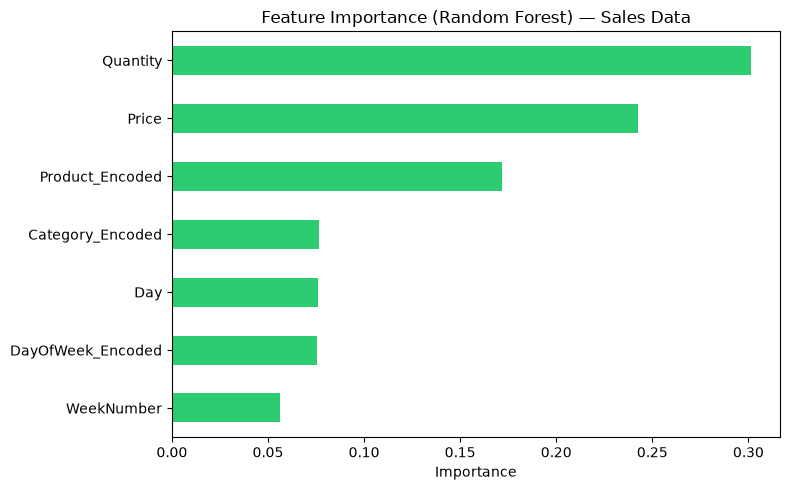


Feature importance values:
Quantity             0.301369
Price                0.242530
Product_Encoded      0.171929
Category_Encoded     0.076282
Day                  0.076045
DayOfWeek_Encoded    0.075433
WeekNumber           0.056413
dtype: float64


In [11]:
# Get feature importances from the Random Forest
importance = pd.Series(rf.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True)

# Color the top 2 features differently
colors = ['#2ecc71' ]

plt.figure(figsize=(8, 5))
importance.plot.barh(color=colors)
plt.title('Feature Importance (Random Forest) — Sales Data')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nFeature importance values:")
print(importance.sort_values(ascending=False))

You'll notice which features contribute the most to predicting the Revenue Tier. Features like **Revenue**, **Price**, and **Revenue_Per_Unit** are likely to be the most important — which makes intuitive sense!

**Why is this useful?**
- Helps you understand your data better
- You can drop unimportant features to simplify your model
- Useful for explaining to non-technical people *what's driving the predictions*

---
## Quick Recap

| Topic | Key Takeaway |
|-------|-------------|
| Ensemble Learning | Use many models and combine their answers — the group is smarter than any individual |
| Random Forest | An ensemble of many decision trees that vote on the final answer |
| Why "Random"? | Each tree gets random data (bagging) and random features — makes them diverse |
| DT vs RF | DT is fast and interpretable but overfits. RF is more accurate and stable but slower |
| Many trees > One tree | Different trees make different mistakes — averaging them out gives a better result |
| Feature Importance | RF tells you which features contribute the most to predictions |

---
*Day 4 done!*